C:\Users\vidhi\AppData\Local\Temp\ipykernel_14680\835832320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_areas, x='New Park Count', y='Area', palette='summer')


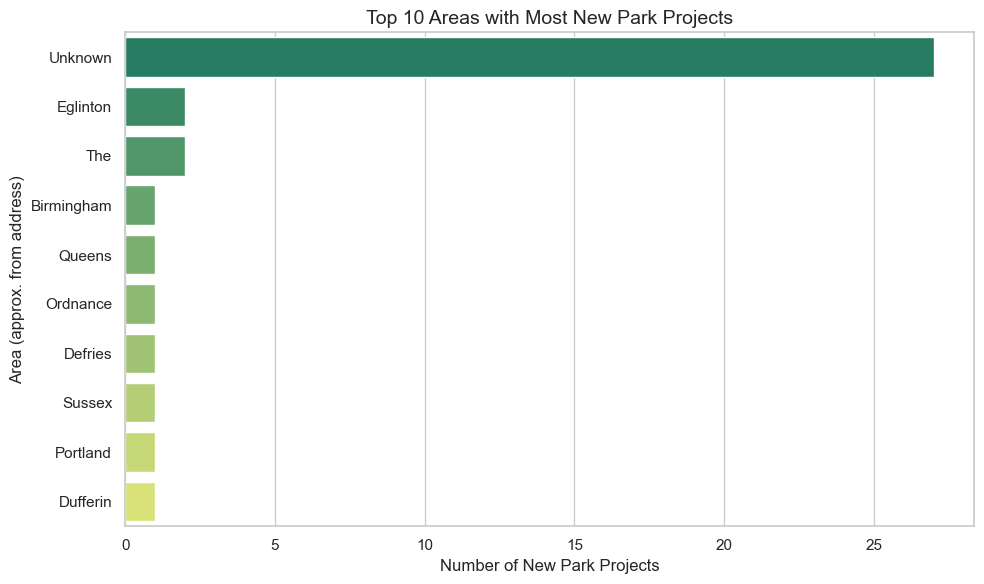

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load your dataset
df = pd.read_csv("park_recreation_projects.csv")

# Step 1: Filter rows where project appears to be a "new park"
mask_new = df['project_name'].str.contains("new park", case=False, na=False) | \
           df['description'].str.contains("new park", case=False, na=False)

df_new_parks = df[mask_new].copy()

# Step 2: Extract approximate area from the address (last street or region name)
def extract_area(address):
    if pd.isnull(address):
        return "Unknown"
    # Try to capture last street/section of the address
    match = re.search(r'\d+\s+(.*)', address)
    if match:
        return match.group(1).split()[0].title()  # take the first word after the number
    return address.title()

df_new_parks['Area'] = df_new_parks['address'].apply(extract_area)

# Step 3: Count new park projects by area
area_counts = df_new_parks['Area'].value_counts().reset_index()
area_counts.columns = ['Area', 'New Park Count']

# Optional: Filter top 10 areas
top_areas = area_counts.head(10)

# Step 4: Plot
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=top_areas, x='New Park Count', y='Area', palette='summer')
plt.title("Top 10 Areas with Most New Park Projects", fontsize=14)
plt.xlabel("Number of New Park Projects")
plt.ylabel("Area (approx. from address)")
plt.tight_layout()
plt.savefig("new_park_projects_by_area.png", dpi=300)
plt.show()
